In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r'C:\Users\user\OneDrive\Desktop\5thsem_ojt\project1_diabetes\data\processed\project1_diabetes_clean.csv',parse_dates=['last_checkup_date'])

In [3]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [4]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

Create an age-band features

In [5]:
df['age_band']=pd.cut(df['age'],bins=[0,35,55,120],labels=('0-35','35-55','over-55'))

In [6]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,over-55
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,35-55
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,35-55
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,over-55
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,over-55
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0,35-55
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0,over-55
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1,over-55
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1,0-35
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1,over-55


Create a BMI category features

In [7]:
df['bmi_category']=pd.cut(df['bmi'],bins=[0,18.5,25,30,100],labels=('underweight','normal','overweight','obese'))

In [8]:
df['bmi_category'].value_counts()

bmi_category
obese          553
overweight     235
normal         124
underweight     38
Name: count, dtype: int64

Create a glucose band features

In [9]:
df['glucose_band']=pd.cut(df['glucose'],bins=[0,100,126,300],labels=('normal','prediabetic','diabetic'))

In [10]:
df['glucose_band'].value_counts()

glucose_band
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

Create an insulin to glucose ratio feature

In [11]:
df['insulin_glucose_ratio']=df['insulin']/df['glucose']

In [12]:
df['insulin_glucose_ratio'].value_counts()

insulin_glucose_ratio
0.953846    9
1.052139    7
1.078261    7
0.898551    6
1.033333    6
           ..
2.163121    1
0.101010    1
0.885714    1
1.984615    1
1.536585    1
Name: count, Length: 743, dtype: int64

In [13]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,over-55,normal,prediabetic,1.000000
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,35-55,obese,diabetic,0.274510
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,35-55,overweight,diabetic,1.119718
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,over-55,overweight,prediabetic,1.024793
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,over-55,normal,prediabetic,0.943925
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0,35-55,normal,diabetic,0.855172
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0,over-55,overweight,normal,1.789474
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1,over-55,obese,diabetic,0.826667
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1,0-35,normal,diabetic,1.751938
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1,over-55,obese,diabetic,1.248447


Check the ratio for impossible value

In [14]:
df['insulin_glucose_ratio'].describe()

count    950.000000
mean       1.213108
std        1.179183
min        0.054348
25%        0.726708
50%        1.052139
75%        1.512831
max       22.745763
Name: insulin_glucose_ratio, dtype: float64

In [15]:
import numpy as np

In [16]:
np.isinf(df['insulin_glucose_ratio']).sum()

np.int64(0)

Create a pregnancies-per-year-of-age feature

In [17]:
df['pregnancies_age_ratio']=df['pregnancies']/df['age']

In [18]:
df['pregnancies_age_ratio'].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancies_age_ratio, dtype: float64

Create a days-since-last-checkup features

In [19]:
reference_date=df['last_checkup_date'].max()

In [20]:
reference_date

Timestamp('2024-12-28 00:00:00')

In [21]:
df['days_since_checkup']=(reference_date-df['last_checkup_date']).dt.days

In [22]:
df['days_since_checkup'].head(10)

0    618
1    239
2    539
3    258
4    336
5    353
6    369
7    191
8    440
9    372
Name: days_since_checkup, dtype: int64

Create a categorical combination  feature

In [23]:
df['activity_smoker']=df['physical_activity']+'/'+df['smoker']

Check the combination features balance

In [24]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO          207
High/NO            195
Low/NO             180
Low/YES             93
Medium/YES          90
High/YES            85
Unknown/NO          36
High/UNKNOWN        22
Unknown/YES         17
Medium/UNKNOWN      12
Low/UNKNOWN          9
Unknown/UNKNOWN      4
Name: count, dtype: int64

Inventory every new column

In [25]:
# activity_smoker = physical activity + smoker
# days_since-checkup = reference - last-checkup_date
# pregnancies_age_ratio = pregnency/age
# insulin_glucose_ratio = insulin\glucose
# glucose_band = glucose
# bmi_category = bmi
# age_band = age

In [26]:
df.shape

(950, 21)

# Exploratory analysis

Re run the group comparison on original features

In [27]:
numeric_cols=['age','pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','diabetes_pedigree']
df.groupby('outcome')[numeric_cols].mean()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,,
0,47.874446,1.828656,112.220027,72.350074,26.370753,131.490399,30.941359,0.441821
1,54.798535,1.915751,131.868081,71.930403,26.047619,132.388278,32.516850,0.511564


In [28]:
engineered_numeric=['insulin_glucose_ratio','days_since_checkup','pregnancies_age_ratio']
df.groupby('outcome')[engineered_numeric].mean()

,insulin_glucose_ratio,days_since_checkup,pregnancies_age_ratio
outcome,,,
0,1.271066,350.304284,0.044392
1,1.069380,366.534799,0.038809


In [29]:
df.head(20)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio,pregnancies_age_ratio,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,over-55,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,35-55,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,35-55,overweight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,over-55,overweight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,over-55,normal,prediabetic,0.943925,0.000000,336,Low/NO
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,...,YES,2024-01-10,0,35-55,normal,diabetic,0.855172,0.000000,353,High/YES
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,...,NO,2023-12-25,0,over-55,overweight,normal,1.789474,0.086207,369,High/NO
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,...,NO,2024-06-20,1,over-55,obese,diabetic,0.826667,0.051724,191,Medium/NO
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,...,UNKNOWN,2023-10-15,1,0-35,normal,diabetic,1.751938,0.187500,440,High/UNKNOWN
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,...,YES,2023-12-22,1,over-55,obese,diabetic,1.248447,0.000000,372,Medium/YES


Rank everything together

In [30]:
group_means=df.groupby('outcome')[numeric_cols+engineered_numeric].mean().T
group_means['gap']=(group_means[1]-group_means[0]).abs()
group_means.sort_values('gap',ascending=False)

outcome,0,1,gap
glucose,112.220027,131.868081,19.648054
days_since_checkup,350.304284,366.534799,16.230515
age,47.874446,54.798535,6.924089
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271066,1.069380,0.201686
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743


State the new Top three 

In [31]:
# glucose 
# days_since_checkup
# age

Cross tabulate the age band against outcome

In [32]:
pd.crosstab(df['age_band'],df['outcome'],normalize='index')

outcome,0,1
age_band,,
0-35,0.789683,0.210317
35-55,0.766871,0.233129
over-55,0.612903,0.387097


Same cross tabulate for bmi_category

In [33]:
pd.crosstab(df['bmi_category'],df['outcome'],normalize='index')

outcome,0,1
bmi_category,,
underweight,0.763158,0.236842
normal,0.750000,0.250000
overweight,0.770213,0.229787
obese,0.676311,0.323689


Same cross tabulate for glucose_category

In [34]:
pd.crosstab(df['glucose_band'],df['outcome'],normalize='index')

outcome,0,1
glucose_band,,
normal,0.901515,0.098485
prediabetic,0.715134,0.284866
diabetic,0.567335,0.432665


In [35]:
import matplotlib.pyplot as plt

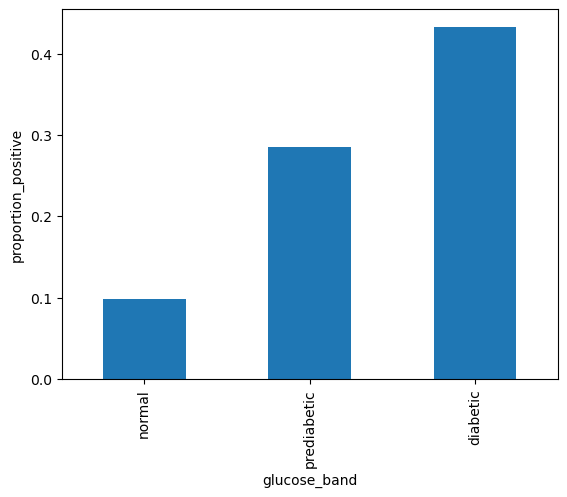

In [36]:
ax=pd.crosstab(df['glucose_band'],df['outcome'],normalize='index')[1].plot(kind='bar')
ax.set_xlabel('glucose_band')
ax.set_ylabel('proportion_positive')
plt.show()

In [39]:
df.to_csv(r'C:\Users\user\OneDrive\Desktop\5thsem_ojt\project1_diabetes\data\processed\hebin_p1w2_features.csv',index=False)

In [40]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio,pregnancies_age_ratio,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,over-55,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,35-55,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,35-55,overweight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,over-55,overweight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,over-55,normal,prediabetic,0.943925,0.000000,336,Low/NO
